Trabajo Practico 3  
Vision por computadora I  
CEIA 2026

Este TP tiene por objetivo localizar el logo de Coca-Cola a partir de una única plantilla (template), pattern.png, combinando comparación de patrones, búsqueda de escala, bordes de Canny y operaciones morfológicas. 

Se resuelven tres tareas: 
1. obtener una detección por imagen,
2. detectar múltiples instancias en coca_multi.png,
3. aplicar el detector múltiple al conjunto completo.

Se organiza el código de tal forma que separamos carga y preprocesamiento, búsqueda, selección de candidatos, visualización y evaluación. Así reutilizamos las funciones entre consignas y se puede identificar qué etapa explica cada resultado.

**Notas**
1. Las cajas se representan como (x, y, ancho, alto) en píxeles de la imagen original.
2. *loc* almacena la esquina superior izquierda y size almacena ancho y alto.
3. *scale* es el factor aplicado al template recortado, no a la imagen. 
4. Los resultados analizados son los guardados en esta versión del notebook.
5. La salida *confidence/conf* representa similitud normalizada, no probabilidad de acierto
6. El campo histórico *psr* calcula un z-score global del mapa de respuesta.
7. Las anotaciones manuales se utilizan para evaluar y no intervienen en la localización automática.

#### *1. Preparación y funciones compartidas*

##### *1.1 Dependencias*

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os   #para manejar rutas

##### *1.2 Información de la imagen: dimensiones, canales e intensidades*

In [ ]:
def InfoImg(img):
  """Resume forma, canales, dtype y estadísticas del array recibido.
  
  img.size cuenta componentes del array (incluye canales), no solo píxeles.
  Las estadísticas de una imagen BGR incluyen sus tres canales.
  """
  channels = img.shape[2] if len(img.shape) == 3 else 1
  
  print('-------------- Info --------------')
  print(f'Size (hxw): {img.shape[0]} x {img.shape[1]} px')
  print('Channels:',channels)
  print('Total pxs:',img.size)
  print('Data type:',img.dtype)
  print('-------------- Stats --------------')
  print('Minimum value of pixel:',np.min(img))
  print('Maximum value of pixel:',np.max(img))
  print('Mean value of intensity:',round(np.mean(img)))

##### *1.3 Rutas de acceso a imagenes y plantilla*

Las rutas son relativas al directorio de trabajo del kernel. Las imagenes se separan del template utilizando las carpetas *images/* y *template/*.   

In [ ]:
# Rutas de imagenes y plantilla
IMAGES_PATH = './images/'
TEMPLATE_PATH = './template/'
TEMPLATE_NAME = 'pattern.png' #mismo template de referencia para las tres consignas

##### *1.4. Métodos, preprocesamiento de bordes y comparación geométrica* 

Funciones: `get_method`, `is_minimization`, `extract_edges`, `compute_iou` y `best_iou`.

`get_method` traduce los nombres configurados a constantes de OpenCV. 

`is_minimization` permite interpretar correctamente el mínimo de SQDIFF o el máximo de correlación. Aunque existe soporte auxiliar para SQDIFF, para las pruebas utilizamos CCOEFF_NORMED y CCORR_NORMED.

`extract_edges` aplica una operación de suavizado con un filtro gaussiano y el detector de bordes Canny con umbrales 50/150. El detector conserva contornos útiles para comparar la forma del logo reduciendo la dependencia del color. Para CCOEFF_NORMED se añade una operación morfológica de dilatación elíptica con un kernel de 3×3 y una iteración, esta operación engrosa levemente los bordes admitiendo pequeños desplazamientos, pero también puede aumentar coincidencias con texturas. Se aplica el mismo tratamiento al template; CCORR conserva el detector Canny sin dilatación.

`compute_iou` calcula la métrica $IoU=A_{intersección}/A_{unión}$, para medir el solapamiento geométrico de dos bounding boxes:

`best_iou` admite una referencia o varias y selecciona el mayor *IoU*. Esto permite validar una detección única frente a cualquiera de los logos anotados en coca_multi.png. No constituye un emparejamiento uno a uno para evaluar un detector múltiple.

In [ ]:
def get_method(method_name):
    """Convierte un nombre configurado como 'cv.TM_CCOEFF_NORMED' a constante.
    
    Se espera un identificador válido de OpenCV; no se evalúa código arbitrario.
    """
    return getattr(cv, method_name.split('.')[1])


def is_minimization(method):
    """En SQDIFF el mejor match es el mínimo; en el resto es el máximo."""
    return method in (cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED)


def extract_edges(gray, low=50, high=150, method=None):
    """Extrae bordes; añade dilatación 3x3 solo para CCOEFF_NORMED.
    
    method debe ser una constante OpenCV. La imagen y el template deben usar el
    mismo método para conservar coherencia en las representaciones.
    """
    # Suavizar antes de Canny reduce contornos producidos por pequeñas cambios
    blurred = cv.GaussianBlur(gray, (3, 3), 0) #kernel gaussiano de 3x3
    edges = cv.Canny(blurred, low, high)

    # Tolerancia espacial pequeña usando dilatación con kernel de 3x3
    if method == cv.TM_CCOEFF_NORMED:
        kernel = cv.getStructuringElement(
            cv.MORPH_ELLIPSE, (3, 3)
        )
        edges = cv.dilate(edges, kernel, iterations=1)

    return edges


def compute_iou(box_a, box_b):
    """Calcula intersección/unión de dos cajas (x, y, ancho, alto).
    
    Se utilizan intervalos geométricos sin sumar un píxel al ancho o alto.
    Si la unión no es positiva, devuelve cero.
    """
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    inter_w = max(0, min(ax + aw, bx + bw) - max(ax, bx))
    inter_h = max(0, min(ay + ah, by + bh) - max(ay, by))
    inter = inter_w * inter_h
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


def best_iou(predicted_box, reference_boxes):
    """Obtiene el mayor IoU entre una predicción y las referencias disponibles
    
    Acepta una caja o una lista de cajas. Una lista vacía devuelve cero
    No realiza asignación uno a uno ni evalúa referencias no anotadas
    """
    # Convierte la lista (o tuplas) de bounding boxes en una matriz de 'mx4' ([x, y, w, h])
    references = np.asarray(reference_boxes).reshape(-1, 4)

    return max(
        (compute_iou(predicted_box, ref) for ref in references),
        default = 0.0
    )

##### *1.5 Carga de imagenes y plantilla* 

Funciones: `load_template`, `load_image` y `list_images`

La plantilla se carga en escala de grises. Otsu invertido genera una máscara para hallar el rectángulo del logo más oscuro que el fondo blanco. Recortamos la imagen en grises, no la máscara, para conservar la información necesaria al redimensionar y extraer bordes. Este recorte reduce la influencia de márgenes blancos y define el origen de todas las escalas; pero igual depende del contraste y fondo del template.

`load_image` retorna las imagenes en BGR para dibujar y en escala de grises para detectar. 

`list_images` ordena los nombres para mantener el mismo recorrido. Los errores de lectura permiten identificar una ruta incorrecta antes de que falle una operación posterior.

El template recortado mide 373 × 115 píxeles en la ejecución guardada. El algoritmo requiere que las dimensiones del template no superen las dimensiones de la imagen en cada comparación.

In [ ]:
def load_template(path=TEMPLATE_PATH, name=TEMPLATE_NAME):
    """Carga la plantilla en grises y recorta el margen con una máscara Otsu.
    
    La máscara localiza el logo oscuro sobre fondo claro y devuelve las
    intensidades originales recortadas, no la máscara binaria.
    """
    gray = cv.imread(os.path.join(path, name), cv.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f'No se encontró el template en {path}{name}')
    
    # Otsu invertido: el logo (oscuro sobre blanco) queda como foreground
    _, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    x, y, w, h = cv.boundingRect(mask)
    # Otsu decide el recorte y la detección trabaja con las intensidades originales
    return gray[y:y + h, x:x + w]


def load_image(name, path=IMAGES_PATH):
    """Devuelve la imagen en BGR y en escala de grises."""
    bgr = cv.imread(os.path.join(path, name))

    if bgr is None:
        raise FileNotFoundError(f'No se pudo leer {path}{name}')
    return bgr, cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)


def list_images(path=IMAGES_PATH):
    """ Filtra y devuelve los archivos del path que terminen en '.png' o '.jpg'
    ordenados alfabéticamente
    """
    format_valid = ('.png', '.jpg')
    return sorted(f for f in os.listdir(path) if f.lower().endswith(format_valid))

##### *1.6 Búsqueda multiescala y medidas de respuesta* 

Funciones: `resize_template`, `compute_response`, `compute_confidence`, `search_scales` y `match_multiscale`.

Se redimensiona el template manteniendo su proporción y se calcula Canny después de cada cambio de tamaño. El flag **INTER_AREA** se usa al reducir mientras que **INTER_CUBIC** al ampliar. Las imágenes de entrada conservan su tamaño y no se construye una pirámide de imágenes.

`cv.matchTemplate` compara la plantilla con cada posición donde cabe dentro de la imagen y devuelve una mapa cuyos valores indican la similitud en cada posición. Después, `cv.minMaxLoc(result)` obtiene la mejor ubicación. El flag **CCORR_NORMED** normaliza el producto de intensidades; **CCOEFF_NORMED** lo calcula tras restar sus medias.

`compute_response` obtiene la mejor posición de cada mapa y estandariza la medida de cuánto sobresale el mejor valor de similitud respecto al resto del mapa de respuesta con la siguiente ecuación:

$$z_{pico}=\frac{R_{max}-\mu_R}{\sigma_R}\$$


Para métodos de mínimo se invierte el numerador. 

`PSR(Peak-to-Sidelobe Ratio)` mide cuánto destaca el máximo de un mapa de respuesta frente a las respuestas que quedan fuera de una pequeña zona alrededor del mismo. En nuestro caso la variable psr almacena cuánto destaca la mejor coincidencia respecto al promedio de todo el mapa. Técnicamente, este cálculo es un z-score global. 

Un valor alto nos ayuda a seleccionar candidatos, pero no confirma por sí solo que correspondan al logo. Si el mapa es plano, se devuelve z=0; el resultado sigue siendo un candidato, pues en la consigna 1 no incorporamos rechazo por umbral.

La búsqueda se realiza con `search_scales` en dos etapas. Primero se prueban 70 tamaños de la plantilla y se conserva la coincidencia con mayor z-score. Después probamos 11 tamaños cercanos a la escala seleccionada, dentro de ±5%, para ajustar la detección sin aumentar demasiado el número de comparaciones. Se descartan las plantillas de menos de 60 píxeles de ancho para reducir falsos positivos causados por detalles del fondo.

`compute_confidence` adapta el score a un indicador en [0,1]. La normalización facilita la presentación, pero no calibra probabilidades ni vuelve comparables los valores de distintos métodos o preprocesamientos.

In [ ]:
def resize_template(template_gray, scale):
    """Escala la plantilla preservando proporción y adaptando interpolación.
    """
    interp = cv.INTER_AREA if scale < 1 else cv.INTER_CUBIC
    return cv.resize(template_gray, None, fx=scale, fy=scale, interpolation=interp)


def compute_response(image_edges, template_edges, method):
    """Devuelve score, esquina del mejor candidato y z-score global
    
    El nombre histórico psr usa media y desviación del mapa completo
    No excluye una vecindad del pico y tampoco representa la probabilidad de acierto
    """
    minimize = is_minimization(method)
    result = cv.matchTemplate(image_edges, template_edges, method)

    # Mantenemos el mapa finito para evitar que NaN/Inf dominen minMaxLoc
    # Los sustitutos son penalizaciones normalizadas, no una prueba de rechazo
    result = np.nan_to_num(result, nan=1.0 if minimize else 0.0,
                           posinf=1.0 if minimize else 0.0, neginf=1.0 if minimize else 0.0)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)
    score, loc = (min_val, min_loc) if minimize else (max_val, max_loc)
    std = result.std()
    if std < 1e-9:   # mapa plano: no hay ningún pico distinguible
        return score, loc, 0.0

    # Este cálculo es el z global sin exclusión alrededor del pico
    psr = ((result.mean() - score) if minimize else (score - result.mean())) / std
    return score, loc, psr


def compute_confidence(score, method):
    """Convierte un score normalizado en un indicador de similitud en [0, 1]
    
    Se invierte SQDIFF para mostrar mayor similitud como mejor coincidencia
    El resultado no es una probabilidad calibrada y se esperan métodos NORMED
    """
    if not np.isfinite(score):
        return 0.0
    return float(np.clip(1.0 - score if is_minimization(method) else score, 0.0, 1.0))


def search_scales(image_edges, template_gray, scales, method):
    """Explora tamaños y conserva el candidato de mayor z-score global
    
    Los bounding boxes quedan en coordenadas originales porque solo cambia la plantilla
    Por otro lado, None indica que ninguna escala cumple las restricciones de tamaño
    """
    best = None
    img_h, img_w = image_edges.shape
    for scale in scales:
        # Redimensionamos antes de aplicar Canny para evitar interpolar bordes binarios
        template_edges = extract_edges(resize_template(template_gray, scale),
                                       method=method)
        t_h, t_w = template_edges.shape
        if t_w < MIN_TEMPLATE_WIDTH or t_h > img_h or t_w > img_w:
            continue
        score, loc, psr = compute_response(image_edges, template_edges, method)

        # Priorizamos las zonas donde la plantilla destaca significativamente más que en el fondo 
        # o las áreas circundantes por lo que un score alto no decide por sí solo
        if best is None or psr > best['psr']:
            best = {'score': float(score), 'loc': loc, 'size': (t_w, t_h),
                    'scale': float(scale), 'psr': float(psr)}
    return best


def match_multiscale(image_edges, template_gray, method_name):
    """Busca tamaños de plantilla y refina la mejor escala dentro de ±5%
    
    La imagen no se escala y tampoco construimos una pirámide de imágenes
    """
    method = get_method(method_name)
    best = search_scales(image_edges, template_gray, SCALES, method)
    if best is None:
        return None

    # Refinamos localmente para reducir el coste frente a una grilla fina en todo el rango
    fine_scales = best['scale'] * np.linspace(1 - REFINE_RANGE, 1 + REFINE_RANGE, 11)
    refined = search_scales(image_edges, template_gray, fine_scales, method)
    
    if refined is not None and refined['psr'] >= best['psr']:
        best = refined
    best['method'] = method_name
    best['confidence'] = compute_confidence(best['score'], method)
    
    return best

##### *1.7 Visualización de una detección y comparación entre métodos*

Dibujamos sobre una copia BGR para no introducir rectángulos o texto en la imagen que posteriormente podría procesarse. El grosor y tamaño de fuente se adaptan a la resolución. Antes de mostrar con Matplotlib se convierte BGR a RGB.

La grilla contiene tantos paneles como resultados recibidos utilizando dos métodos. Las etiquetas históricas **conf** y **PSR** deben interpretarse como similitud y z global, respectivamente. El cálculo de la posición del texto intenta evitar el borde superior, pero no garantiza que todo el rótulo quede dentro de los límites en cualquier escena.

In [ ]:
def draw_detection(image_bgr, detection, color=(0, 255, 0)):
    """Dibuja una caja y sus indicadores sobre una copia BGR.
    
    La etiqueta PSR conserva el nombre histórico del z-score global.
    """
    # Separamos anotación y datos
    # Las cajas nunca deben entrar al detector
    output = image_bgr.copy()
    x, y = detection['loc']
    w, h = detection['size']
    thickness = max(1, round(min(output.shape[:2]) / 200))
    font_scale = max(0.4, min(output.shape[:2]) / 700)

    cv.rectangle(output, (x, y), (x + w, y + h), color, thickness)
    label = f"{detection['confidence']:.2f} | PSR {detection['psr']:.1f}"
    (text_w, text_h), _ = cv.getTextSize(label, cv.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    
    # Si no cabe arriba intenamos ubicar debajo y no hay recorte completo del rótulo
    text_y = y - 4 if y - text_h - 4 > 0 else y + h + text_h + 4   # dentro de la imagen
    cv.rectangle(output, (x, text_y - text_h - 2), (x + text_w + 4, text_y + 3), color, -1)
    cv.putText(output, label, (x + 2, text_y), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (0, 0, 0), thickness, cv.LINE_AA)
    return output


def plot_methods_grid(image_name, image_bgr, detections):
    """Compara visualmente los métodos recibidos en una fila de paneles de 1x2    
    """
    fig, axes = plt.subplots(1, len(detections), figsize=(15, 5))
    for ax, det in zip(axes, detections):
        if det is None:
            ax.set_title('Sin detección')
        else:
            drawn = draw_detection(image_bgr, det)
            ax.imshow(cv.cvtColor(drawn, cv.COLOR_BGR2RGB))
            ax.set_title(f"{det['method']}\nconf={det['confidence']:.2f} | escala={det['scale']:.2f}")
        ax.axis('off')
    fig.suptitle(image_name, fontsize=14)
    plt.tight_layout()
    plt.show()

#### *2.1 Detección del logo en cada imagen*

El objetivo es devolver un bounding boxes correspondiente a un logo en cada imagen del conjunto. El método no elige la misma instancia cuando existen varias. Se compara la localización mediante anotaciones manuales, manteniendo separadas la selección automática y la evaluación.

##### *2.1. Procesamiento de cada imagen con los métodos configurados*

La carga se realiza una vez por imagen. Los bordes se preparan dentro del recorrido de métodos porque CCOEFF incorpora dilatación y CCORR no. Cada configuración ejecuta su búsqueda multiescala y conserva una sola respuesta. La función puede devolver resultados sin dibujarlos mediante show=False, separando cómputo y presentación.

In [ ]:
def analyze_image(image_name, template_gray, show=True):
    """Obtiene una detección por método y opcionalmente dibuja la comparación
    """
    image_bgr, image_gray = load_image(image_name)

    detections = []

    for method_name in METHODS:
        method = get_method(method_name)

        image_edges = extract_edges(
            image_gray,
            method=method
        )

        detection = match_multiscale(
            image_edges,
            template_gray,
            method_name
        )
        detections.append(detection)

    if show:
        plot_methods_grid(image_name, image_bgr, detections)

    return detections

##### *2.2. Resumen de similitud, escala y localización mediante IoU*

La tabla asocia imagen y método con similitud, escala e IoU. El símbolo ✔ indica IoU ≥ 0.5 respecto de la mejor referencia disponible; no deriva del score de correlación. Cuando hay varias referencias, la columna histórica IoU corresponde a `IoU` máximo.

Las referencias no se utilizan para elegir posición ni escala. En imágenes con varias instancias, este criterio evita penalizar un logo real por no coincidir con una única caja fijada arbitrariamente. Si no existe anotación se informa «-». Los resultados `None` se omiten en esta tabla.

In [46]:
def print_summary(all_results):
    """Tabla resumen método x imagen con confianza (y IoU si hay ground truth)."""
    print(f"{'imagen':<22}{'método':<22}{'conf':>6}{'escala':>8}{'IoU':>7}  ok")
    for image_name, detections in all_results.items():
        for det in detections:
            if det is None:
                continue
            iou_txt, ok_txt = '-', ''
            if image_name in GROUND_TRUTH:
                box = (*det['loc'], *det['size'])
                iou = best_iou(box, GROUND_TRUTH[image_name])
                iou_txt, ok_txt = f'{iou:.2f}', ('✔' if iou >= 0.5 else '✘')
            print(f"{image_name:<22}{det['method']:<22}{det['confidence']:>6.2f}"
                  f"{det['scale']:>8.2f}{iou_txt:>7}  {ok_txt}")

##### *2.3. Información de dimensiones y estadísticas de cada imagen*

In [43]:
list_img = list_images()
for img in list_img:
    img,_ = load_image(img)

    InfoImg(img)

    # plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    # plt.show()

-------------- Info --------------
Size (hxw): 1389 x 1389 px
Channels: 3
Total pxs: 5787963
Data type: uint8
-------------- Stats --------------
Minimum value of pixel: 0
Maximum value of pixel: 255
Mean value of intensity: 151
-------------- Info --------------
Size (hxw): 500 x 207 px
Channels: 3
Total pxs: 310500
Data type: uint8
-------------- Stats --------------
Minimum value of pixel: 0
Maximum value of pixel: 255
Mean value of intensity: 140
-------------- Info --------------
Size (hxw): 363 x 233 px
Channels: 3
Total pxs: 253737
Data type: uint8
-------------- Stats --------------
Minimum value of pixel: 0
Maximum value of pixel: 255
Mean value of intensity: 125
-------------- Info --------------
Size (hxw): 598 x 799 px
Channels: 3
Total pxs: 1433406
Data type: uint8
-------------- Stats --------------
Minimum value of pixel: 0
Maximum value of pixel: 255
Mean value of intensity: 96
-------------- Info --------------
Size (hxw): 493 x 715 px
Channels: 3
Total pxs: 1057485
Da

Las imágenes `coca_logo_1.png` y `coca_logo_2.png` tienen anchos de 207 y 233 píxeles, menores que los 373 de la plantilla recortada. No es posible comparar directamente esos tamaños con matchTemplate; por lo tanto, la búsqueda debe reducir la plantilla. En las demas imagenes el logo es mayor, de modo que también se exploran ampliaciones. El requisito es que la plantilla no exceda a la imagen y la igualdad de dimensiones también es válida.

##### *2.4. Métodos, escalas y estructura de las referencias*  

Comparamos dos métodos normalizados. Las escalas geométricas de 0.15 a 3.5 ofrecen pasos relativos aproximadamente uniformes, adecuados para tamaños que varían por factores multiplicativos. `MIN_TEMPLATE_WIDTH=60` descarta escalas demasiado pequeñas en la búsqueda base y el refinamiento local es de ±5%.

`GROUND_TRUTH` almacena una tupla por imagen o una lista de tuplas si hay varias referencias. En esta celda la inicializamos como vacío. Las referencias actuales se generan en el bloque interactivo posterior.

In [ ]:
# Metodos a evaluar
METHODS = [
    'cv.TM_CCOEFF_NORMED',
    'cv.TM_CCORR_NORMED'
]

# Bounding boxes reales (x, y, w, h) para validar con IoU
# Ejemplo: 'coca_logo_1.png': (30, 180, 140, 60)
GROUND_TRUTH = {} # Reinicializar esta celda borra las anotaciones en memoria

# Pasos relativos regulares, aplicados a la plantilla recortada
SCALES = np.geomspace(0.15, 3.5, 70)
MIN_TEMPLATE_WIDTH = 60                # evita templates diminutos que matchean con cualquier textura
REFINE_RANGE = 0.05                    # refinamiento del ±5% alrededor de la mejor escala

##### *2.5. Anotación manual de cajas de referencia*

La anotación registra `(x,y,w,h)` a resolución original. Al cambiar el tamaño de la ventana no redimensiona el array utilizado para seleccionar. Se encierra el logo completo con un margen consistente, se confirma con Enter o espacio y se cancela con C. Una caja de ancho o alto cero no se guarda.

Esta operación produce referencias de evaluación; no reemplaza la detección automática. Deben elegirse por inspección del objeto y no copiando los bounding boxes que se predicen. Para conservarlas tras reiniciar el kernel se debe registrar el diccionario final en una celda o archivo. Los resultados impresos permanecen visibles, pero no restauran variables en memoria.

In [ ]:
def annotate_ground_truth(image_name):
    """Anota una caja a resolución original y actualiza GROUND_TRUTH
    
    Enter/espacio confirma; C cancela. Una caja vacía no modifica el registro
    Devuelve la tupla (x, y, ancho, alto) o None si se cancela
    """
    image_bgr, _ = load_image(image_name)
    window_name = f'Ground truth: {image_name}'

    # Ajustamos la ventana sin redimensionar los datos de la imagen
    h, w = image_bgr.shape[:2]
    display_scale = min(1.0, 1100 / w, 750 / h)

    cv.namedWindow(
        window_name,
        cv.WINDOW_NORMAL | cv.WINDOW_KEEPRATIO
    )
    cv.resizeWindow(
        window_name,
        round(w * display_scale),
        round(h * display_scale)
    )

    try:
        roi = cv.selectROI(
            window_name,
            image_bgr,
            showCrosshair=True,
            fromCenter=False
        )
    finally:
        cv.destroyWindow(window_name)

    x, y, width, height = map(int, roi)

    if width == 0 or height == 0:
        print(f'Selección cancelada: {image_name}')
        return None

    box = (x, y, width, height)
    # Las selecciones repetidas reemplazan temporalmente esta clave
    # El bucle de coca_multi reúne después las cuatro tuplas en una lista
    GROUND_TRUTH[image_name] = box

    print('Caja guardada: (x, y, ancho, alto)')
    print(f"'{image_name}': {box},")

    # Verificamos visualmente la anotación
    preview = image_bgr.copy()
    cv.rectangle(
        preview,
        (x, y),
        (x + width, y + height),
        (0, 255, 0),
        2
    )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(preview, cv.COLOR_BGR2RGB))
    plt.title(f'{image_name} | Ground truth: {box}')
    plt.axis('off')
    plt.show()

    return box

##### *2.6. Construcción de referencias para las siete imágenes*

El bucle anota una caja por escena y cuatro logos distintos en `coca_multi.png`. En cada selección se utiliza la función anterior; al finalizar se reúne la lista. Si se cancela la anotación múltiple, se restaura el valor previo para evitar dejar un conjunto incompleto accidentalmente.

Nota: las cuatro cajas de coca_multi forman una anotación parcial. Se elige mas de una debido a que hay varias opciones que consideramos validas por inspección. El numero elegido fue suficiente para comprobar las instancias seleccionadas en la consigna 1, pero no para clasificar todas las detecciones de las consignas 2 y 3 como aciertos o falsos positivos.

Caja guardada: (x, y, ancho, alto)
'COCA-COLA-LOGO.jpg': (91, 467, 1168, 409),


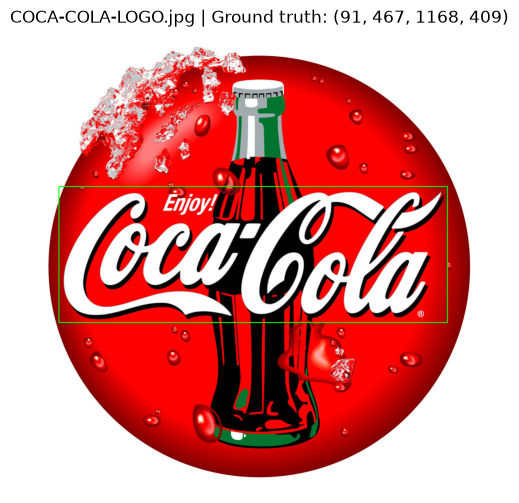

Caja guardada: (x, y, ancho, alto)
'coca_logo_1.png': (43, 205, 139, 61),


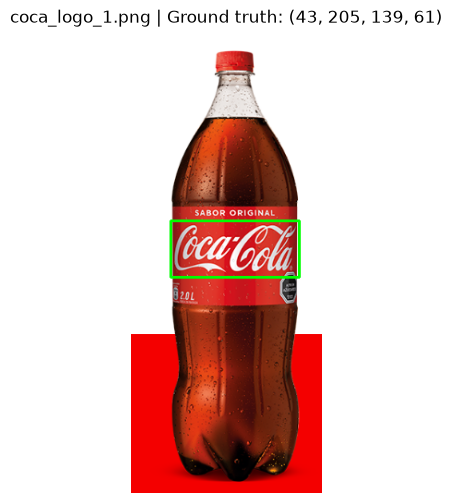

Caja guardada: (x, y, ancho, alto)
'coca_logo_2.png': (16, 122, 187, 91),


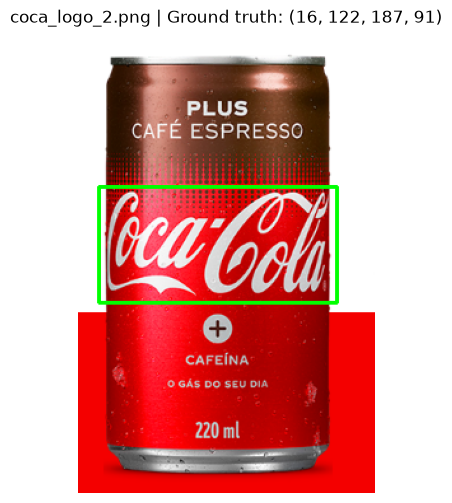

Anota el logo 1/4 en coca_multi.png
Caja guardada: (x, y, ancho, alto)
'coca_multi.png': (278, 148, 82, 38),


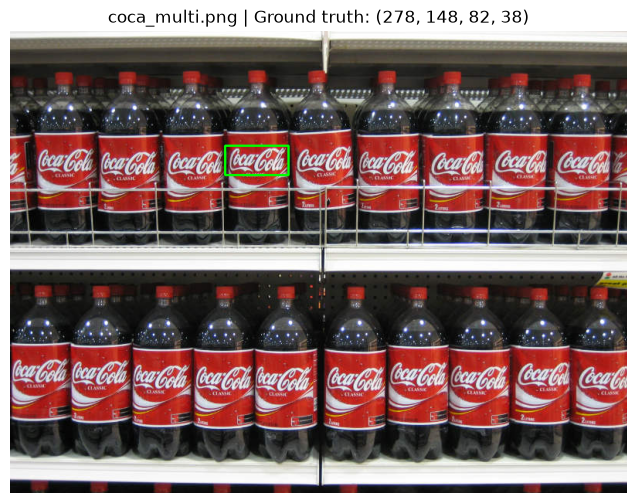

Anota el logo 2/4 en coca_multi.png
Caja guardada: (x, y, ancho, alto)
'coca_multi.png': (448, 151, 80, 39),


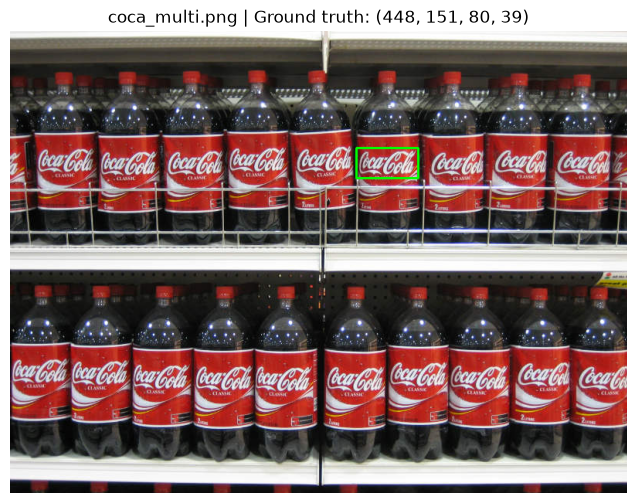

Anota el logo 3/4 en coca_multi.png
Caja guardada: (x, y, ancho, alto)
'coca_multi.png': (236, 431, 83, 38),


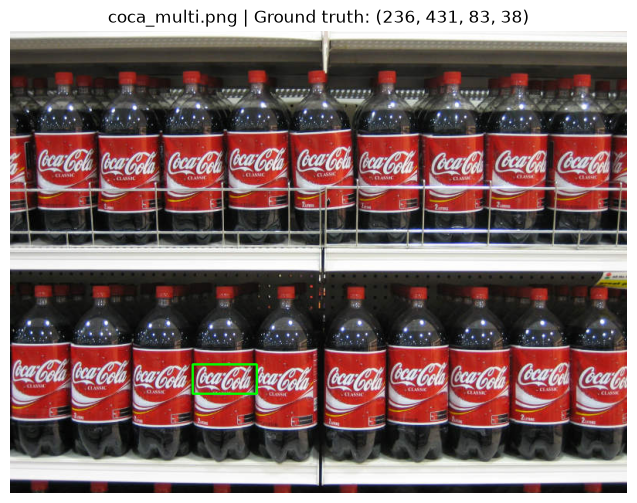

Anota el logo 4/4 en coca_multi.png
Caja guardada: (x, y, ancho, alto)
'coca_multi.png': (489, 424, 80, 41),


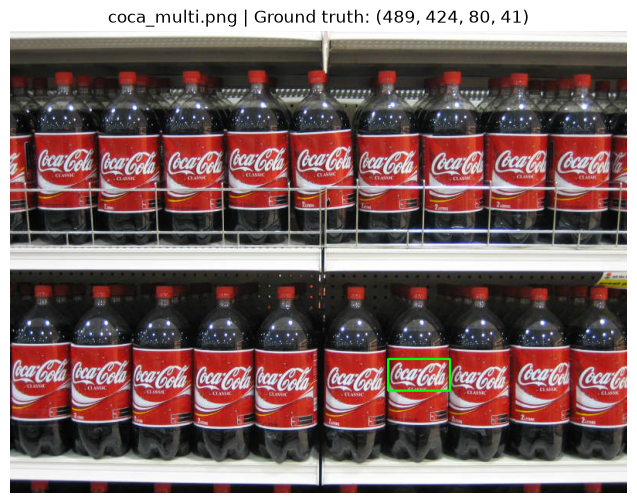

Caja guardada: (x, y, ancho, alto)
'coca_retro_1.png': (106, 108, 508, 160),


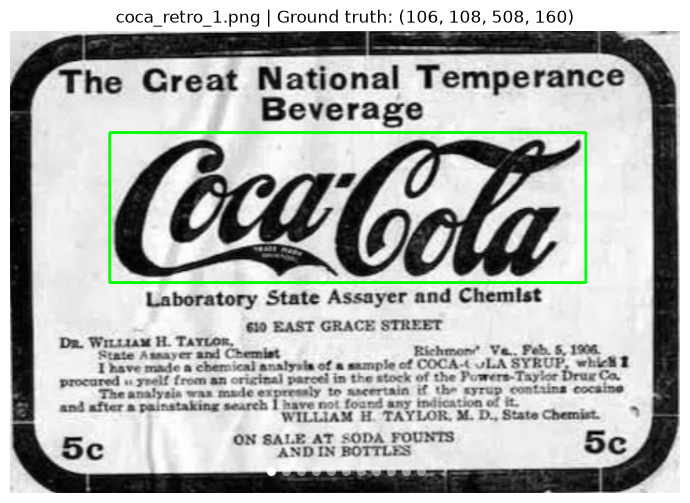

Caja guardada: (x, y, ancho, alto)
'coca_retro_2.png': (64, 192, 147, 53),


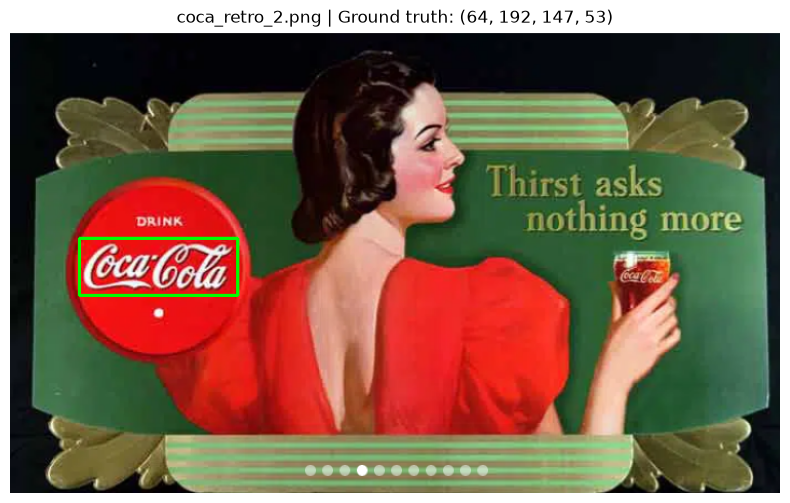

Caja guardada: (x, y, ancho, alto)
'logo_1.png': (214, 206, 241, 101),


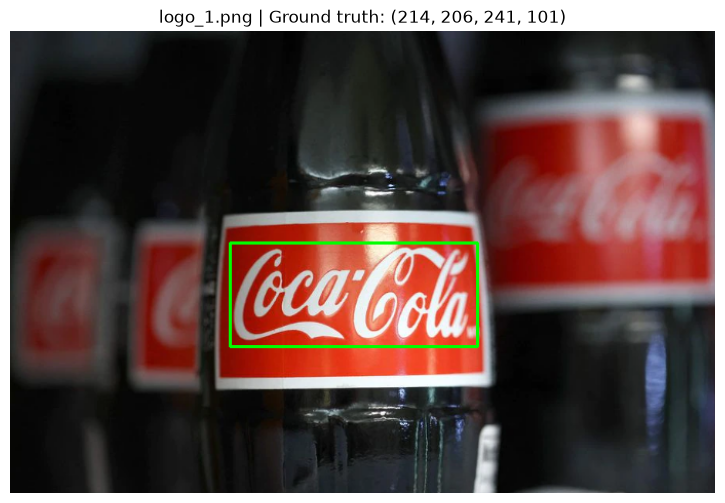

In [ ]:
for image_name in list_images():

    if image_name == 'coca_multi.png':
        boxes = []
        previous = GROUND_TRUTH.get(image_name)

        for i in range(4):
            print(f'Anota el logo {i + 1}/4 en {image_name}')
            box = annotate_ground_truth(image_name)

            if box is None:
                break

            boxes.append(box)

        # Guardamos las cuatro referencias juntas
        if len(boxes) == 4:
            GROUND_TRUTH[image_name] = boxes
        else:
            # Restauramos la referencia anterior si se cancela.
            if previous is None:
                GROUND_TRUTH.pop(image_name, None)
            else:
                GROUND_TRUTH[image_name] = previous

            print('Anotación cancelada; no se guardaron cambios.')

    else:
        annotate_ground_truth(image_name)

##### *2.7 Ejecución de la detección única y tabla de resultados*

Cargamos la plantilla una sola vez y se reutiliza en todas las escenas. Se guardan las detecciones en un diccionario por nombre de imagen, presentamos las comparaciones y se imprime el resumen. La variable `results` permite analizar después la consigna 1 sin repetir su cálculo.

Template: (373, 115) px


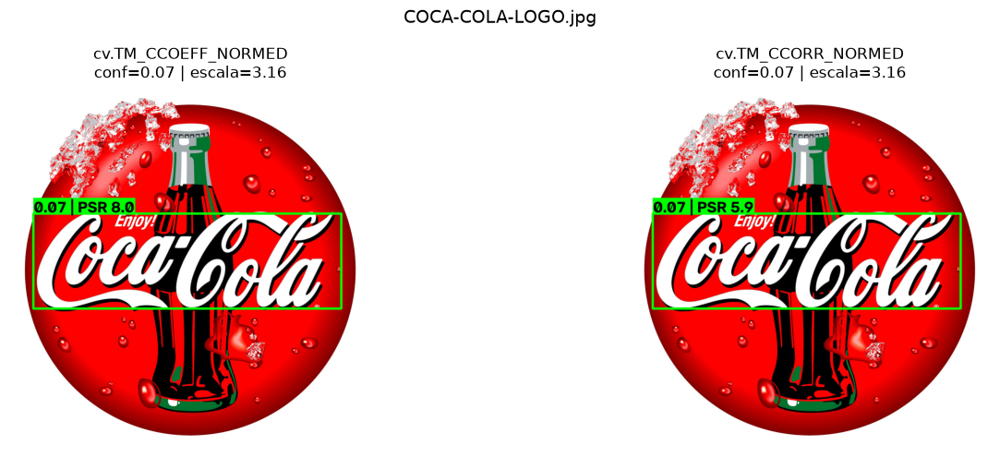

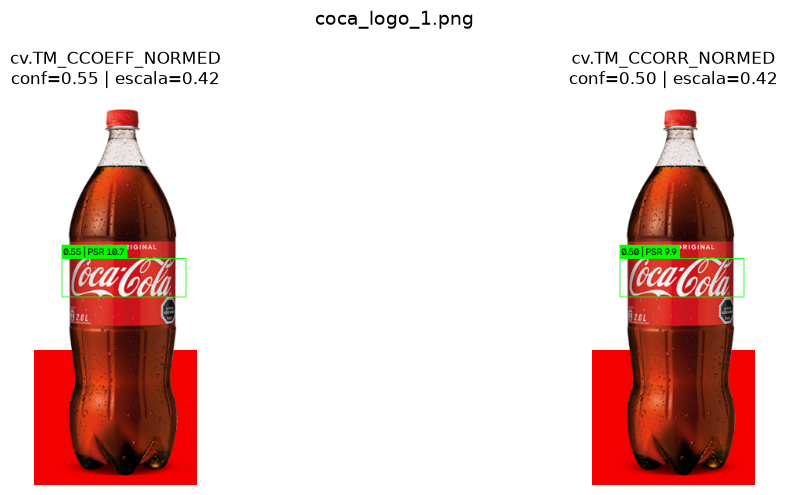

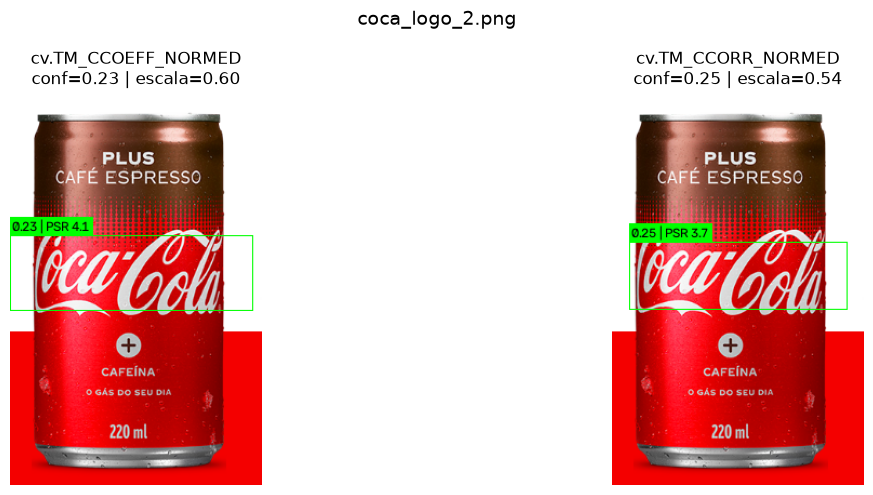

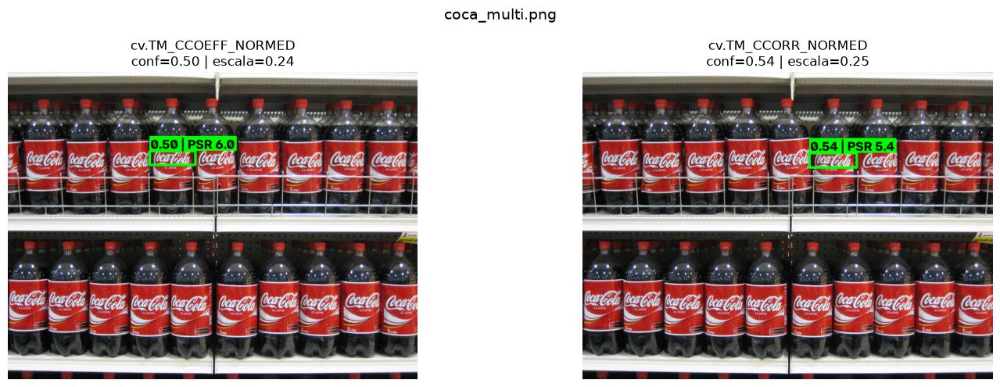

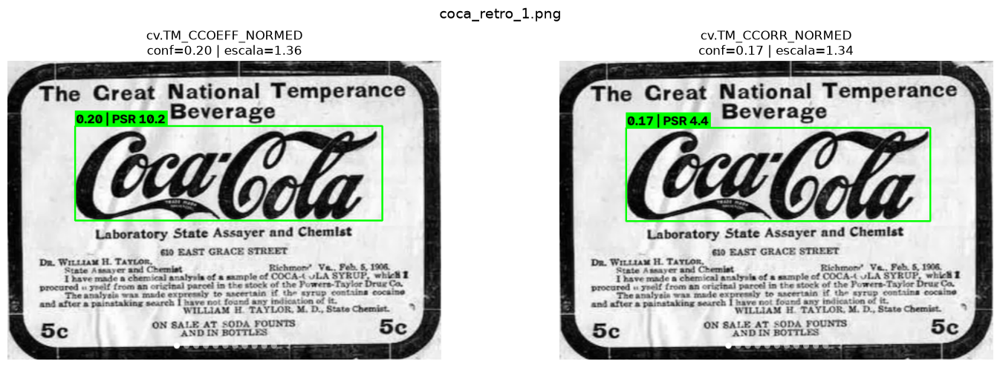

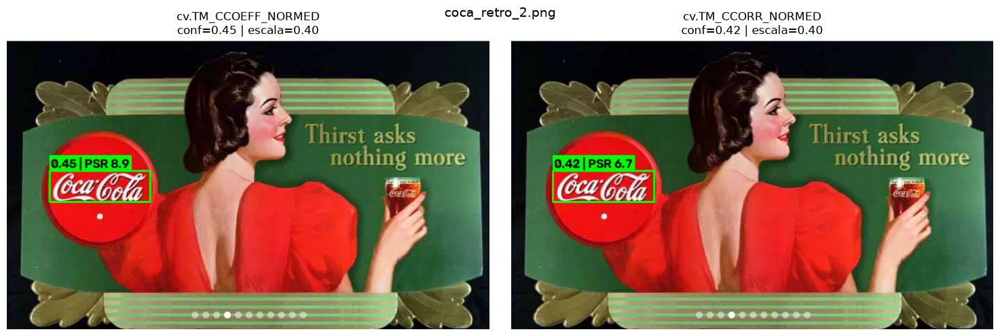

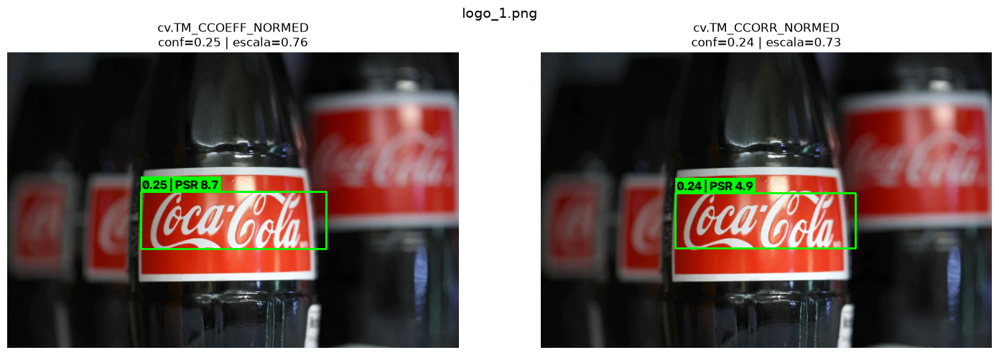

imagen                método                  conf  escala    IoU  ok
COCA-COLA-LOGO.jpg    cv.TM_CCOEFF_NORMED     0.07    3.16   0.88  ✔
COCA-COLA-LOGO.jpg    cv.TM_CCORR_NORMED      0.07    3.16   0.88  ✔
coca_logo_1.png       cv.TM_CCOEFF_NORMED     0.55    0.42   0.72  ✔
coca_logo_1.png       cv.TM_CCORR_NORMED      0.50    0.42   0.72  ✔
coca_logo_2.png       cv.TM_CCOEFF_NORMED     0.23    0.60   0.66  ✔
coca_logo_2.png       cv.TM_CCORR_NORMED      0.25    0.54   0.65  ✔
coca_multi.png        cv.TM_CCOEFF_NORMED     0.50    0.24   0.67  ✔
coca_multi.png        cv.TM_CCORR_NORMED      0.54    0.25   0.65  ✔
coca_retro_1.png      cv.TM_CCOEFF_NORMED     0.20    1.36   0.95  ✔
coca_retro_1.png      cv.TM_CCORR_NORMED      0.17    1.34   0.95  ✔
coca_retro_2.png      cv.TM_CCOEFF_NORMED     0.45    0.40   0.86  ✔
coca_retro_2.png      cv.TM_CCORR_NORMED      0.42    0.40   0.85  ✔
logo_1.png            cv.TM_CCOEFF_NORMED     0.25    0.76   0.75  ✔
logo_1.png            cv.TM_CCORR

In [48]:
def run_task_1():
    template_gray = load_template()
    print(f'Template: {template_gray.shape[::-1]} px')
    all_results = {}
    for image_name in list_images():
        all_results[image_name] = analyze_image(image_name, template_gray, show=True)
    print_summary(all_results)
    return all_results


results = run_task_1()

##### *2.8 Análisis de resultados de la consigna 1*

Los resultados guardados presentan una detección por imagen y método, con IoU máximo superior a 0.5 en los 14 casos. Las figuras sitúan el bounding box sobre logos reales del conjunto. Esto sustenta el objetivo de localización única en estas siete imagenes.

| Imagen | IoU máximo CCOEFF | IoU máximo CCORR | Interpretación |
|---|---:|---:|---|
| COCA-COLA-LOGO.jpg | 0.88 | 0.88 | Se localiza el logo de gran tamaño |
| coca_logo_1.png | 0.72 | 0.72 | La caja recupera el logo de la botella |
| coca_logo_2.png | 0.66 | 0.65 | El ajuste es menor en el logo sobre la lata |
| coca_multi.png | 0.67 | 0.65 | Se valida cada selección frente a las cuatro referencias disponibles |
| coca_retro_1.png | 0.95 | 0.95 | Alto acuerdo con la caja del cartel retro |
| coca_retro_2.png | 0.86 | 0.85 | Se localiza el logo principal del cartel |
| logo_1.png | 0.75 | 0.75 | Se recupera el logo de la botella central |

Los valores de la tabla se transcriben de la salida redondeada y no de una nueva medición. La escala varía aproximadamente entre 0.24 y 3.16 respecto de la plantilla recortada, lo que muestra la utilidad de buscar tamaños diferentes. La variación de IoU refleja márgenes, proporciones y diferencias de apariencia, pero no permite atribuir por sí sola el error a una causa específica.

Para la imagen `COCA-COLA-LOGO` se tiene una similitud cercana a 0.07 con ambos métodos y, aun así, IoU=0.88, por lo que podemos decir que un valor pequeño no equivale necesariamente a una mala localización. Para el caso de `coca_multi` contiene varias instancias y los métodos pueden seleccionar distintas posiciones válidas. El signo ✔ expresa el cumplimiento del criterio geométrico respecto de referencias existentes.

#### *3. Consigna 2: Detección múltiple en coca_multi.png*

Se mantiene `pattern.png` y se extiende la búsqueda desde un único máximo a varios máximos por escala. Las coincidencias repetidas debidas a desplazamientos y cambios de tamaño se reducen mediante NMS. En esta consigna necesitamos distinguir localizar varias instancias y lograr que se recuperan todas.

##### *3.1 Banda de escalas, umbral z y supresión de duplicados*

La escala base proviene de la consigna 1. Se exploran 15 factores entre 0.75 y 1.30 veces esa escala, aprovechando que las botellas de esta imagen presentan tamaños relativamente similares.

`Z_THRESHOLD=4.0` selecciona picos suficientemente sobresaliente según el mapa de cada escala. 

`NMS_IOU=0.3` elimina candidatos que se solapan con una caja de mayor prioridad. Este IoU de NMS no es el umbral IoU=0.5 empleado para evaluar las referencias: el primero uno controla redundancia y el segundo la correspondencia con una anotación.

In [ ]:
SCALE_SPAN = (0.75, 1.30)   # rango relativo alrededor de la escala hallada en la consigna 1
N_SCALES = 15
Z_THRESHOLD = 4.0           # umbral sobre el z-score del pico
NMS_IOU = 0.3               # Supresión de duplicados distinto de IoU=0.5 de evaluación

##### *3.2 Máximos locales, candidatos y NMS entre escalas*

Funciones: `local_max`, `collect_candidates`, `non_max_suppression`, `select_detections`, `sweep_threshold` y `draw_detections`.

`local_max` aplica dilatación sobre el mapa de respuesta para encontrar valores máximos en una vecindad. Esta operación es distinta de dilatar los bordes binarios en `extract_edges`. Las ventanas de aproximadamente medio ancho y alto de la plantilla, permiten reducir picos vecinos antes de construir las cajas, mientras que una meseta puede aportar más de un candidato.

`collect_candidates` prepara la plantilla en cada escala y registra siete campos: `(x,y,w,h,score,z,scale)`. La estandarización usa la media y desviación del mapa completo; no representa una probabilidad ni supone que el fondo sea gaussiano.

`select_detections` filtra por z y aplica NMS a los candidatos reunidos de todas las escalas, ordenándolos por z. 

La `NMS voraz` conserva el candidato prioritario y descarta los que lo solapan más de lo permitido. Así evitamos contar un mismo logo varias veces. Un umbral demasiado estricto también puede suprimir objetos distintos cercanos.

`sweep_threshold` reutiliza candidatos y mide cuántas cajas sobreviven en cada umbral. Una meseta ayuda a analizar sensibilidad, pero no demuestra por sí sola que las identidades o posiciones se mantengan. 

`draw_detections` muestra las similitudes de las cajas finales sobre una copia de la escena.

In [ ]:
def local_max(result, win_w, win_h):
    """Encuentra máximos de respuesta por comparación con una dilatación local
    
    La entrada es un mapa flotante, no una imagen de bordes binarios
    En mesetas puede devolver más de un punto con igual valor
    """
    local = cv.dilate(result, np.ones((win_h, win_w), np.uint8))
    ys, xs = np.nonzero(result >= local)
    return xs, ys


def non_max_suppression(boxes, scores, iou_threshold):
    """Conserva índices de cajas prioritarias mediante NMS voraz por IoU
    
    Los boxes tiene formato (N,4), (x,y,w,h) y los scores definen la prioridad
    Eliminar duplicados no equivale a emparejar con referencias reales
    """
    # Mayor prioridad primero: las cajas perdedoras pueden venir de otra escala
    order = np.argsort(scores)[::-1]
    keep = []
    x1, y1 = boxes[:, 0], boxes[:, 1]
    x2, y2 = x1 + boxes[:, 2], y1 + boxes[:, 3]
    areas = boxes[:, 2] * boxes[:, 3]
    while order.size:
        i = order[0]
        keep.append(i)
        rest = order[1:]
        inter = (np.maximum(0, np.minimum(x2[i], x2[rest]) - np.maximum(x1[i], x1[rest])) *
                 np.maximum(0, np.minimum(y2[i], y2[rest]) - np.maximum(y1[i], y1[rest])))
        iou = inter / (areas[i] + areas[rest] - inter)
        order = rest[iou <= iou_threshold]   # descarta los que se solapan demasiado con el mejor
    return keep


def collect_candidates(image_edges, template_gray, method_name, scales, z_min):
    """Reúne máximos por escala como (x,y,w,h,score,z,scale).
    
    Solo admite métodos de máximo. z_min permite conservar candidatos para
    el barrido posterior
    """
    method = get_method(method_name)
    if is_minimization(method):
        raise ValueError('Usar un método de máximo (CCOEFF_NORMED o CCORR_NORMED)')
    candidates = []
    for scale in scales:
        template_edges = extract_edges(
            resize_template(template_gray, scale),
            method=method
        )

        t_h, t_w = template_edges.shape
        if t_h > image_edges.shape[0] or t_w > image_edges.shape[1]:
            continue
        result = np.nan_to_num(cv.matchTemplate(image_edges, template_edges, method))
        z_map = (result - result.mean()) / (result.std() + 1e-9)
        xs, ys = local_max(result, max(3, t_w // 2), max(3, t_h // 2))
        for x, y in zip(xs, ys):
            if z_map[y, x] >= z_min:
                candidates.append((x, y, t_w, t_h, result[y, x], z_map[y, x], scale))
    return np.array(candidates)


def select_detections(candidates, z_threshold=Z_THRESHOLD, iou_threshold=NMS_IOU):
    """Filtra por z, aplica NMS entre escalas y construye las detecciones
    
    La prioridad de NMS se toma de la columna z, no del score mostrado
    Los valores predeterminados se fijan al definir esta función
    """
    if len(candidates) == 0:
        return []
    kept = candidates[candidates[:, 5] >= z_threshold]
    if len(kept) == 0:
        return []

    # Columna 5 = z: determina qué caja conserva NMS entre escalas
    keep = non_max_suppression(kept[:, :4], kept[:, 5], iou_threshold)
    return [{'loc': (int(kept[i, 0]), int(kept[i, 1])),
             'size': (int(kept[i, 2]), int(kept[i, 3])),
             'confidence': float(np.clip(kept[i, 4], 0, 1)),
             'z': float(kept[i, 5]), 'scale': float(kept[i, 6])} for i in keep]


def sweep_threshold(candidates, z_values, iou_threshold=NMS_IOU):
    """Cuenta detecciones tras umbral y NMS para cada z del barrido
    
    La estabilidad del conteo no garantiza estabilidad de las cajas.
    """
    return [(z, len(select_detections(candidates, z, iou_threshold))) for z in z_values]


def draw_detections(image_bgr, detections, color=(0, 255, 0)):
    """Dibuja múltiples cajas y similitudes sin alterar la imagen original
    """
    output = image_bgr.copy()
    font_scale = max(0.35, min(output.shape[:2]) / 1100)
    thickness = max(1, round(min(output.shape[:2]) / 400))
    for det in detections:
        x, y = det['loc']
        w, h = det['size']
        cv.rectangle(output, (x, y), (x + w, y + h), color, thickness)
        text_y = y - 3 if y > 12 else y + h + 12
        cv.putText(output, f"{det['confidence']:.2f}", (x, text_y), cv.FONT_HERSHEY_SIMPLEX,
                   font_scale, (0, 255, 255), thickness, cv.LINE_AA)
    return output

##### *3.3 Ejecución multiescala y barrido del umbral*

La ejecución estima la escala base, reúne candidatos desde el menor z del barrido y selecciona el resultado final. Pasar explícitamente `Z_THRESHOLD` y `NMS_IOU` evita depender de valores predeterminados capturados al definir `select_detections`.

La gráfica combina la localización y la sensibilidad al umbral para facilitar su inspección. El mínimo de `z_values` debe ser menor o igual que el umbral final. Si los candidatos se descartan antes, bajar después el umbral no los recupera. Los datos mostrados usan z desde 3 hasta 6 en pasos de 0.5.

In [ ]:
def run_task_2(image_name='coca_multi.png', method_name='cv.TM_CCOEFF_NORMED',
               z_values=(3, 4, 5, 6, 7, 8, 10)):
    """Ejecuta detección múltiple y análisis de sensibilidad
    
    Devuelve detecciones y pares (z, cantidad). La escala base proviene de la
    búsqueda única y reutilizamos la plantilla para todas las instancias
    """
    method = get_method(method_name)
    template_gray = load_template()
    image_bgr, image_gray = load_image(image_name)
    image_edges = extract_edges(
            image_gray,
            method=method
        )

    # La escala base sale de la detección única de la consigna 1
    base_scale = match_multiscale(image_edges, template_gray, method_name)['scale']
    scales = base_scale * np.linspace(SCALE_SPAN[0], SCALE_SPAN[1], N_SCALES)

    candidates = collect_candidates(image_edges, template_gray, method_name, scales, z_min=min(z_values))
    sweep = sweep_threshold(candidates, z_values)
    
    # Pasamos los umbrales actuales evitando los valores predeterminados antiguos
    detections = select_detections(
        candidates,
        z_threshold=Z_THRESHOLD,
        iou_threshold=NMS_IOU
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1.3]})
    axes[0].imshow(cv.cvtColor(draw_detections(image_bgr, detections), cv.COLOR_BGR2RGB))
    axes[0].set_title(f'{image_name} | {method_name}\n{len(detections)} detecciones '
                      f'(z≥{Z_THRESHOLD}, IoU NMS={NMS_IOU})')
    axes[0].axis('off')
    axes[1].plot([s[0] for s in sweep], [s[1] for s in sweep], 'o-')
    axes[1].axvline(Z_THRESHOLD, ls='--', c='r')
    axes[1].set(xlabel='umbral z', ylabel='nº de detecciones', title='Barrido del umbral')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return detections, sweep

##### *3.4 Experimento con CCOEFF_NORMED y bordes dilatados*

Se utiliza el mismo preprocesamiento que en la consigna 1 y se muestra un barrido alrededor del umbral adoptado. Este experimento produce 18 cajas a z≥4.

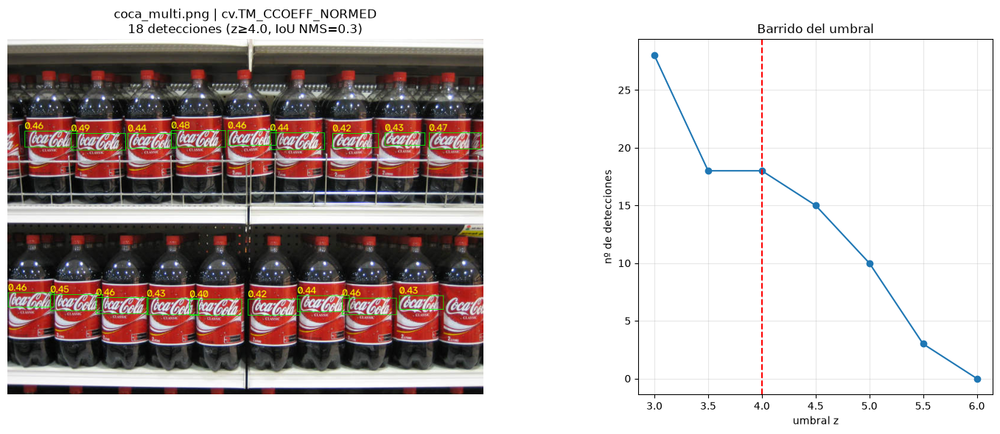

In [70]:
# Solo utilizar como metodos cv.TM_CCOEFF_NORMED o cv.TM_CCORR_NORMED
detections, sweep = run_task_2(
    method_name='cv.TM_CCOEFF_NORMED',
    z_values=(3, 3.5, 4, 4.5, 5, 5.5, 6)
) 

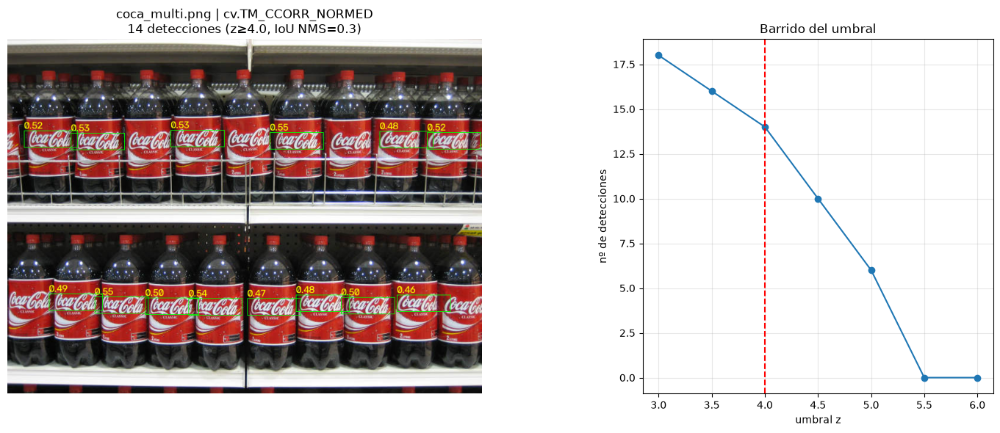

In [71]:
detections, sweep = run_task_2(
    method_name='cv.TM_CCORR_NORMED',
    z_values=(3, 3.5, 4, 4.5, 5, 5.5, 6)
)

##### *3.6 Análisis de resultados de la consigna 2*

Con z≥4 e IoU NMS=0.3, CCOEFF con dilatación devuelve 18 cajas y CCORR sin dilatación 14. En las figuras, las cajas corresponden visualmente a logos distintos y no se observan duplicados evidentes. CCOEFF recupera más instancias bajo estas configuraciones, pero esta comparación no separa el efecto del método y el de la morfología.

| Umbral z | CCOEFF + dilatación | CCORR sin dilatación |
|---:|---:|---:|
| 3.0 | 28 | 18 |
| 3.5 | 18 | 16 |
| 4.0 | 18 | 14 |
| 4.5 | 15 | 10 |
| 5.0 | 10 | 6 |
| 5.5 | 3 | 0 |
| 6.0 | 0 | 0 |

El intervalo 3.5–4 mantiene 18 detecciones CCOEFF, mientras que subir el umbral reduce la cantidad y se omiten logos que siguen siendo visibles. Con z=3 aparecen diez cajas adicionales respecto de z=4, cuya validez no está establecida solo por el conteo. La meseta y la inspección visual justifican z=4 como elección empírica para esta imagen.

Las figuras muestran logos de los extremos sin caja, algunos recortados. No podemos afirmar la recuperación total ni calculamos la precisión cuantitativa a partir de las cuatro referencias parciales. 

Con NMS logramos eliminar las redundancias del detector y por otro lado, encontramos múltiples localizaciones con la misma plantilla, validando visualmente la correspondencia en esta imagen.

#### *4. Consigna 3: Aplicación del detector múltiple al conjunto completo*

La generalización aquí significa ejecutar una misma configuración sobre las siete imagenes proporcionadas, sin seleccionar parámetros por nombre de archivo.

Se reutiliza el detector múltiple y se incorpora una comprobación de cantidad de bordes. No implica que existe invariancia ante cualquier escala, perspectiva, orientación, desenfoque o imagen externa.

##### *4.1. Configuración común del detector generalizado*

Seleccionamos CCOEFF_NORMED con dilatación, banda de escala ±10%, z mínimo final de 3.8 e IoU NMS de 0.1. 

La banda más estrecha reduce variantes de tamaño alrededor de la mejor escala, asumiendo que las instancias detectables de una misma imagen tienen tamaños similares. No cubrimos automáticamente escenas con varios tamaños muy diferentes.

El NMS de 0.1 es más estricto que el de 0.3 de la consigna 2, asi que suprimimos candidatos con menor solapamiento. El rango de cantidad relativa de bordes [0.75,2.0] complementa el z-score. Estos parámetros son empíricos, explorados en este conjunto, y no provienen de una validación independiente.

In [ ]:
# ----------------------------- Configuración consigna 3 -----------------------------
DETECTION_METHOD = 'cv.TM_CCOEFF_NORMED'   # un solo método para estimar la escala y detectar
SCALE_SPAN_T3 = (0.90, 1.10)               # banda estrecha: los logos de una imagen tienen tamaño similar
Z_THRESHOLD_T3 = 3.8                       # con bordes dilatados los z son menores que antes
NMS_IOU_T3 = 0.1                           # NMS estricto: descarta picos desplazados que solapan al logo real
DENSITY_RANGE = (0.75, 2.0)                # razón de píxeles activos caja/plantilla a la misma escala

##### *4.2. Filtrado por cantidad de bordes, detección y cobertura de referencias*

Funciones: `filter_by_edge_density`, `detect_all_logos` y `evaluate_detections`

El filtro calcula la razón entre el número de píxeles activos en la caja y en la plantilla procesada a su escala. Al tener igual área, la razón equivale a comparar sus densidades; no compara intensidades ni confirma la forma. Se usa max(1,…) para evitar dividir por cero.

`detect_all_logos` encadena escala base, candidatos, umbral, NMS y filtro de bordes. El filtro se ejecuta después de NMS; un candidato suprimido no vuelve a evaluarse si la caja que lo suprimió se descarta por densidad.

`evaluate_detections` pregunta, para cada referencia, si existe alguna predicción con IoU≥0.5. Devuelve referencias recuperadas y referencias disponibles. No aplica asignación uno a uno, no cuenta predicciones sobrantes y no calcula precisión, recall completo ni F1. Por ello su salida 4/4 en coca_multi describe las cuatro anotaciones, no los 18 logos detectados.

In [ ]:
def filter_by_edge_density(detections, image_edges, template_gray, method, density_range=DENSITY_RANGE):
    """Filtra por razón de píxeles activos caja/plantilla a escala comparable
    
    La clave density almacena una razón, no una densidad absoluta
    La cantidad de bordes complementa el z, pero no verifica identidad
    """
    kept = []
    for det in detections:
        x, y = det['loc']
        w, h = det['size']
        template_edges = extract_edges(resize_template(template_gray, det['scale']), method=method)
        
        # Razon de píxeles activos
        ratio = np.count_nonzero(image_edges[y:y + h, x:x + w]) / max(1, np.count_nonzero(template_edges))
        if density_range[0] <= ratio <= density_range[1]:
            kept.append({**det, 'density': float(ratio)})
    return kept


def detect_all_logos(image_gray, template_gray, method_name=DETECTION_METHOD):
    """Aplica escala, candidatos, umbral, NMS y filtro de bordes
    
    Devuelve detecciones y escala base, o ([], None).
    """
    method = get_method(method_name)
    image_edges = extract_edges(image_gray, method=method)
    best = match_multiscale(image_edges, template_gray, method_name)   # escala base (consigna 1)
    if best is None:
        return [], None
    scales = best['scale'] * np.linspace(SCALE_SPAN_T3[0], SCALE_SPAN_T3[1], N_SCALES)
    candidates = collect_candidates(image_edges, template_gray, method_name, scales, z_min=3.0)
    detections = select_detections(candidates, Z_THRESHOLD_T3, NMS_IOU_T3)
    
    # Filtro posterior a NMS
    detections = filter_by_edge_density(detections, image_edges, template_gray, method)
    return detections, best['scale']

 
def evaluate_detections(image_name, detections, iou_threshold=0.5):
    """Cuenta referencias con alguna predicción que supera el IoU requerido
    
    Devuelve (referencias recuperadas, referencias disponibles)
    """
    gt_boxes = np.asarray(GROUND_TRUTH[image_name]).reshape(-1, 4)
    pred_boxes = [(*d['loc'], *d['size']) for d in detections]

    # Cuenta referencias cubiertas, considerando que una predicción podría cubrir más de una
    # No clasificamos las predicciones sobrantes como falsos positivos
    found = sum(any(compute_iou(tuple(gt), p) >= iou_threshold for p in pred_boxes) for gt in gt_boxes)
    return found, len(gt_boxes)


##### *4.3 Ejecución del conjunto y visualización de resultados*

Dividimos la ventana de figura en 2×4 para mostrar las siete imágenes y ocultamos el panel sobrante. Cada fila de la tabla informa escala base, cantidad de detecciones y cobertura de las referencias disponibles. Se muestran solo los seis z más altos cuando hay más detecciones.La escala impresa corresponde al mejor candidato inicial.

imagen                 escala  n_det  GT hallados   z de las detecciones
COCA-COLA-LOGO.jpg       3.16      1          1/1   [8.0]
coca_logo_1.png          0.42      1          1/1   [10.7]
coca_logo_2.png          0.60      1          1/1   [4.1]
coca_multi.png           0.24     18          4/4   [6.0, 5.9, 5.8, 5.6, 5.6, 5.6] ...
coca_retro_1.png         1.36      1          1/1   [10.2]
coca_retro_2.png         0.40      1          1/1   [8.9]
logo_1.png               0.76      1          1/1   [8.7]


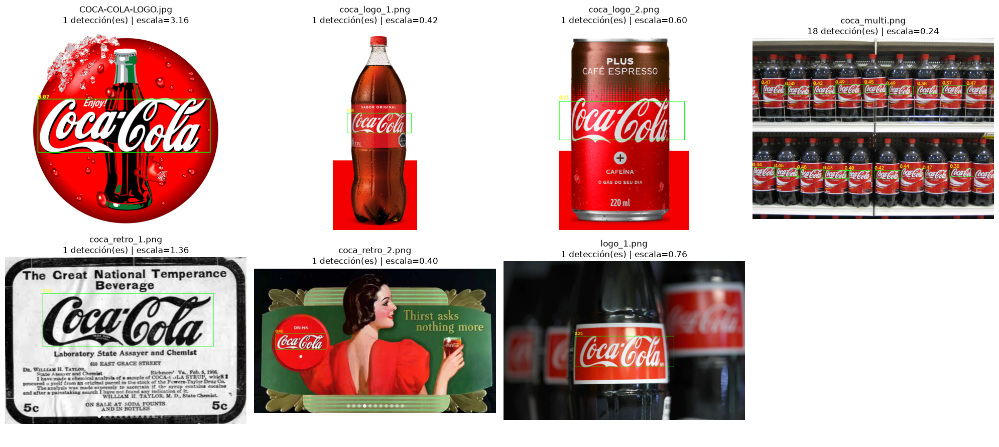

In [ ]:
def run_task_3():
    """Aplica la configuración común y resume detecciones y referencias cubiertas
    
    La grilla fija admite hasta ocho imagenes
    """
    template_gray = load_template()
    names = list_images()
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    print(f"{'imagen':<22}{'escala':>7}{'n_det':>7}{'GT hallados':>13}   z de las detecciones")

    for ax, name in zip(axes.ravel(), names):
        image_bgr, image_gray = load_image(name)
        detections, scale = detect_all_logos(image_gray, template_gray)
        
        # Ground Truth encontrados
        found, total = evaluate_detections(name, detections) if name in GROUND_TRUTH else (0, 0)
        ax.imshow(cv.cvtColor(draw_detections(image_bgr, detections), cv.COLOR_BGR2RGB))
        ax.set_title(f'{name}\n{len(detections)} detección(es) | escala={scale:.2f}')
        ax.axis('off')

        zs = sorted((round(d['z'], 1) for d in detections), reverse=True)
        print(f"{name:<22}{scale:>7.2f}{len(detections):>7}{f'{found}/{total}':>13}   {zs[:6]}{' ...' if len(zs) > 6 else ''}")
    
    for ax in axes.ravel()[len(names):]:   # apaga los ejes sobrantes de la grilla
        ax.axis('off')
    plt.tight_layout()
    plt.show()


run_task_3()

##### *4.4 Análisis de resultados de la consigna 3*

La misma configuración produce 24 detecciones en siete imágenes: 18 en coca_multi y una en cada una de las otras seis. La cobertura de las referencias guardadas es la siguiente:

| Imagen | Escala base | Detecciones | Referencias recuperadas/disponibles |
|---|---:|---:|---:|
| COCA-COLA-LOGO.jpg | 3.16 | 1 | 1/1 |
| coca_logo_1.png | 0.42 | 1 | 1/1 |
| coca_logo_2.png | 0.60 | 1 | 1/1 |
| coca_multi.png | 0.24 | 18 | 4/4 |
| coca_retro_1.png | 1.36 | 1 | 1/1 |
| coca_retro_2.png | 0.40 | 1 | 1/1 |
| logo_1.png | 0.76 | 1 | 1/1 |

Se recuperan 10 de 10 referencias anotadas con el criterio IoU≥0.5 implementado. Este resultado describe la cobertura de anotaciones; no significa precisión=100% o recall=100% sobre todos los logos.

La grilla ubica las cajas sobre los logos principales o sobre varias botellas de coca_multi. El detector se adapta al tamaño dominante de cada imagen sin cambiar parámetros. La banda de ±10% y el NMS más estricto conservan 18 cajas en coca_multi, pero con ese conteo igual al de la consigna 2 no podemos demostrar igualdad exacta de cajas.

La generalización demostrada es aplicación de un mismo procedimiento al conjunto dado, con recuperación de sus referencias anotadas.

En conclusión, la solución final muestra que una plantilla, bordes y búsqueda de tamaño pueden localizar el logo en escenas de aspecto diferente. En la consigna 1 validamos una caja por imagen; en la consigna 2 extendimos la selección a múltiples máximos y utilizamos NMS; y en la consigna 3 aplicamos una configuración común y añadimos una comprobación de cantidad de bordes.